In [1]:
# Python packages
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
from os.path import join
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
adata_hvg = sc.read_h5ad("/data/akalin/akollot/anglemania_benchmark/simulated/integration/batch.facLoc0.3_de.facLoc0.1_nbatch5_ngroup4_groupCells1000/scvi/batch.facLoc0.3_de.facLoc0.1_nbatch5_ngroup4_groupCells1000_hvg.h5ad")
adata_angl = sc.read_h5ad("/data/akalin/akollot/anglemania_benchmark/simulated/integration/batch.facLoc0.3_de.facLoc0.1_nbatch5_ngroup4_groupCells1000/scvi/batch.facLoc0.3_de.facLoc0.1_nbatch5_ngroup4_groupCells1000_angl.h5ad")

In [8]:
adata_hvg

AnnData object with n_obs × n_vars = 20000 × 2000
    obs: 'Cell', 'Batch', 'Group', 'ExpLibSize', '_scvi_batch', '_scvi_labels'
    var: 'Gene', 'BaseGeneMean', 'OutlierFactor', 'GeneMean', 'BatchFacBatch1', 'BatchFacBatch2', 'BatchFacBatch3', 'BatchFacBatch4', 'BatchFacBatch5', 'DEFacGroup1', 'DEFacGroup2', 'DEFacGroup3', 'DEFacGroup4'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p'
    obsm: 'X_emb'
    layers: 'counts', 'logcounts'

In [5]:
def prep_umap(adata, embedding = 'X_emb'):
    sc.pp.neighbors(adata, use_rep = embedding)
    sc.tl.umap(adata)
    return adata

adata_hvg = prep_umap(adata_hvg)
adata_angl = prep_umap(adata_angl)

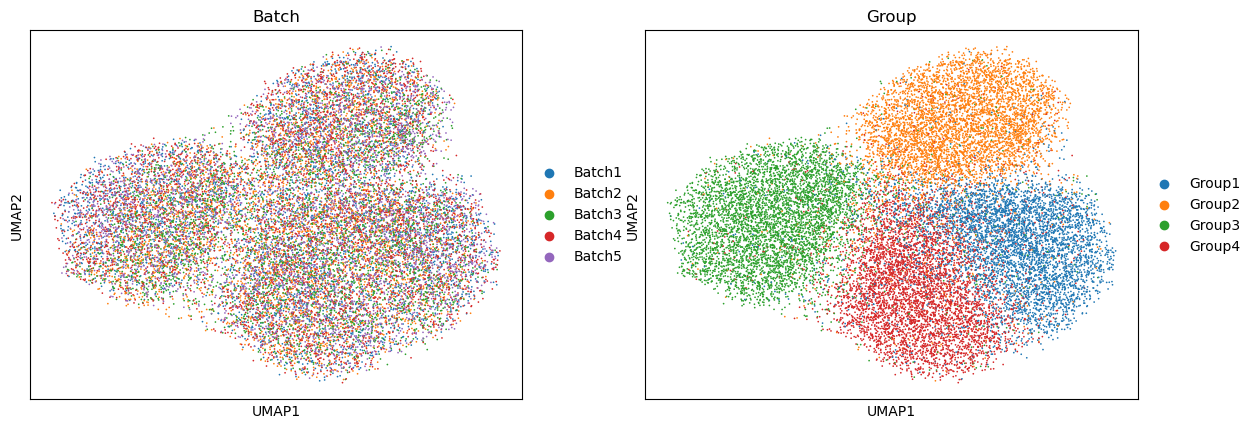

In [11]:
sc.pl.umap(adata_hvg, color = ['Batch', 'Group'])

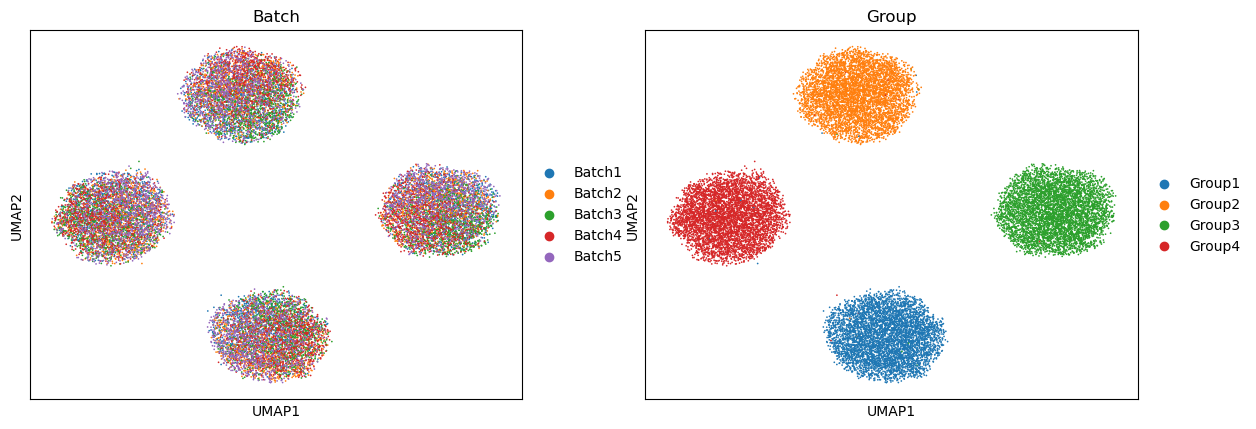

In [12]:
sc.pl.umap(adata_angl, color = ['Batch', 'Group'])

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Plot the first UMAP
output_dir = "/home/akollot/projects/CRC1588/dataset_integration/anglemania_benchmark/output/plots/bm_simulated_visualization/umaps"
def plot_umap(adata, 
              color_by=None, 
              xlims=(-7, 16), 
              ylims=(-6, 17), 
              point_size=10):
    """
    Plots a UMAP scatter plot from an AnnData object using Seaborn and optionally saves it.

    Parameters:
        adata (AnnData): The AnnData object containing UMAP coordinates.
        color_by (str): Column name in `adata.obs` to color the points by (e.g., 'Batch' or 'Group').
        xlims (tuple): x-axis limits as (min, max). Default is (-7, 14).
        ylims (tuple): y-axis limits as (min, max). Default is (-6, 15).
        point_size (int): Size of points in the scatter plot. Default is 10.
        save (str): File path to save the plot as a PNG file. If None, the plot will not be saved. Default is None.
    """
    # Create a DataFrame for the UMAP coordinates and metadata
    df = pd.DataFrame(adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
    

    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))    
    if not color_by==None:
        df[color_by] = adata.obs[color_by].values
        scatter_plot = sns.scatterplot(
            data=df,
            x='UMAP1',
            y='UMAP2',
            hue=color_by,
            palette='dark',
            alpha=0.7,
            s=point_size,
            ax=ax
        )
    # Adjust the legend point size
        handles, labels = scatter_plot.get_legend_handles_labels()
        scatter_plot.legend(
            handles=handles,
            labels=labels,
            scatterpoints=1,
            fontsize=15,
            title=color_by,
            title_fontsize=18,
            markerscale=30 / point_size  # Scale legend points
        )
        
    else:
        sns.scatterplot(
            data=df,
            x='UMAP1',
            y='UMAP2',
            hue=color_by,
            palette='viridis',
            alpha=0.7,
            s=point_size,
            ax=ax
          )
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_xlabel('UMAP1', fontsize = 20)
    ax.set_ylabel('UMAP2', fontsize = 20)


    return ax


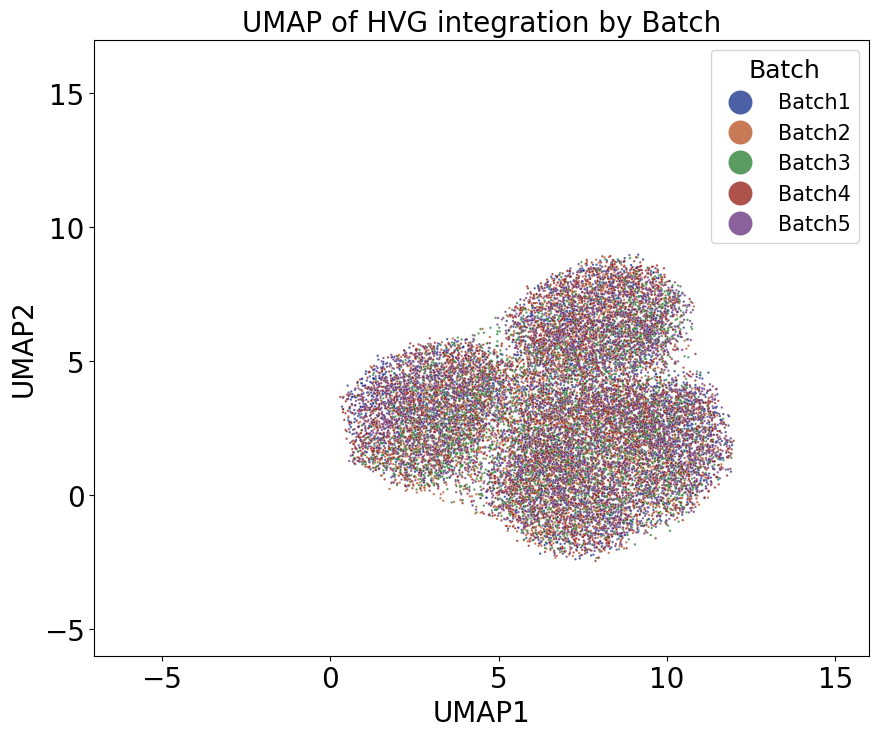

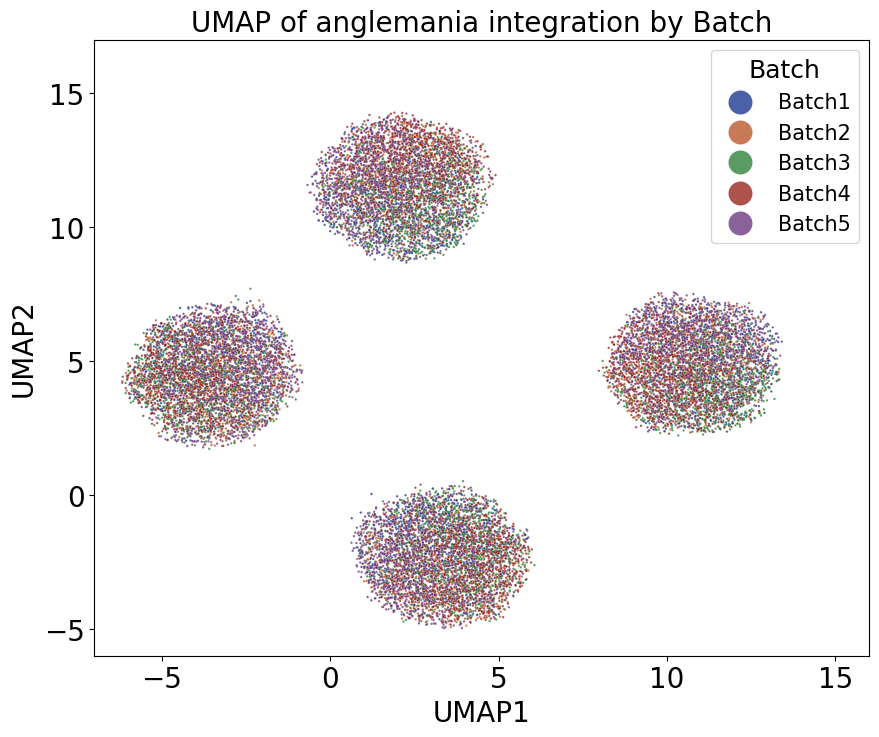

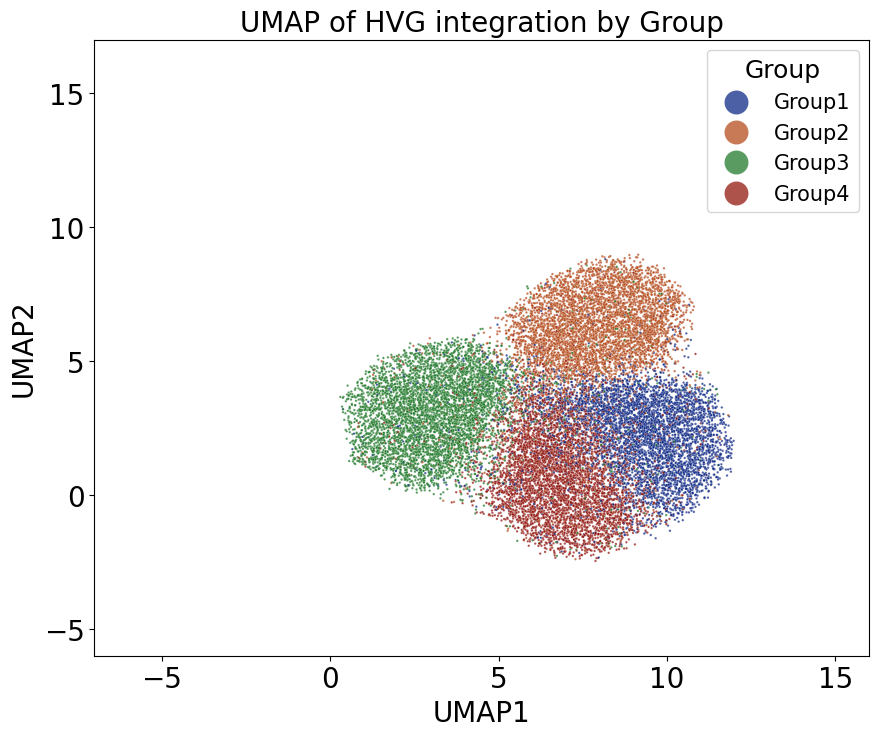

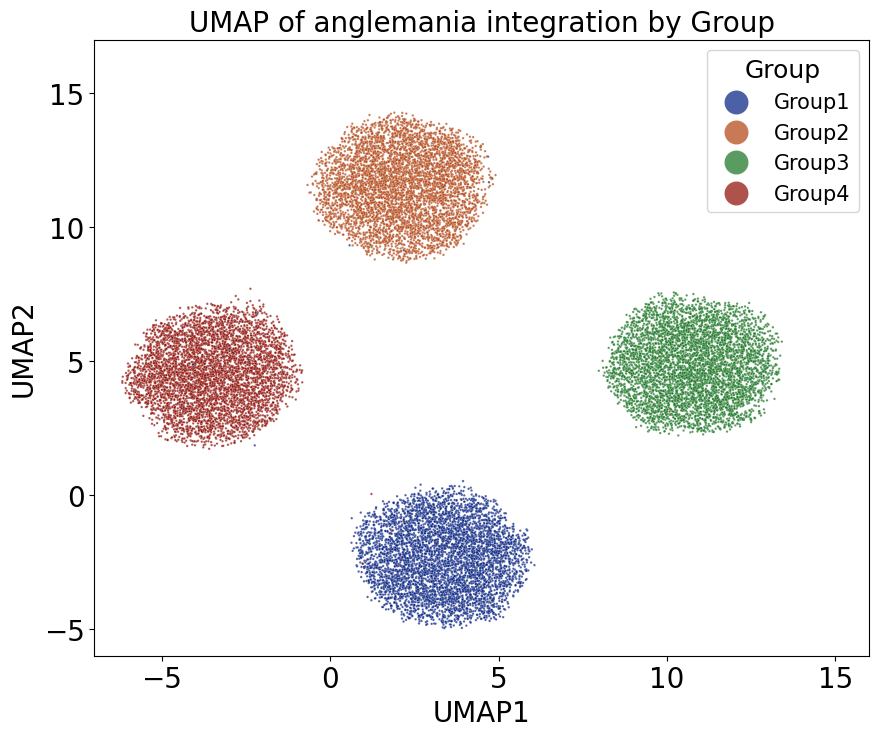

In [94]:
p = plot_umap(
    adata_hvg,
    color_by="Batch",
    point_size=3
    )
p.set_title('UMAP of HVG integration by Batch', fontsize = 20)
plt.savefig(join(output_dir, "umap_batch.facLoc0.3_de.facLoc0.1_nbatch5_ngroup4_groupCells1000_hvg.png"), dpi=300, bbox_inches='tight')
p = plot_umap(
    adata_angl, 
    color_by="Batch",
    point_size=3
    )
p.set_title('UMAP of anglemania integration by Batch', fontsize = 20)
plt.savefig(join(output_dir, "umap_batch.facLoc0.3_de.facLoc0.1_nbatch5_ngroup4_groupCells1000_angl.png"), dpi=300, bbox_inches='tight')
p = plot_umap(
    adata_hvg, 
    color_by="Group",
    point_size=3
    )
p.set_title('UMAP of HVG integration by Group', fontsize = 20)
plt.savefig(join(output_dir, "umap_group.facLoc0.3_de.facLoc0.1_nbatch5_ngroup4_groupCells1000_hvg.png"), dpi=300, bbox_inches='tight')
p = plot_umap(
    adata_angl, 
    color_by="Group",
    point_size=3
    )
p.set_title('UMAP of anglemania integration by Group', fontsize = 20)
plt.savefig(join(output_dir, "umap_group.facLoc0.3_de.facLoc0.1_nbatch5_ngroup4_groupCells1000_angl.png"), dpi=300, bbox_inches='tight')


2025-02-11 17:03:58.965697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-11 17:03:59.202429: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-11 17:03:59.241142: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-11 17:03:59.520265: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-11 17:04:05.062248: W tensorflow/comp

Text(0.5, 1.0, 'UMAP of anglemania integration by Group')

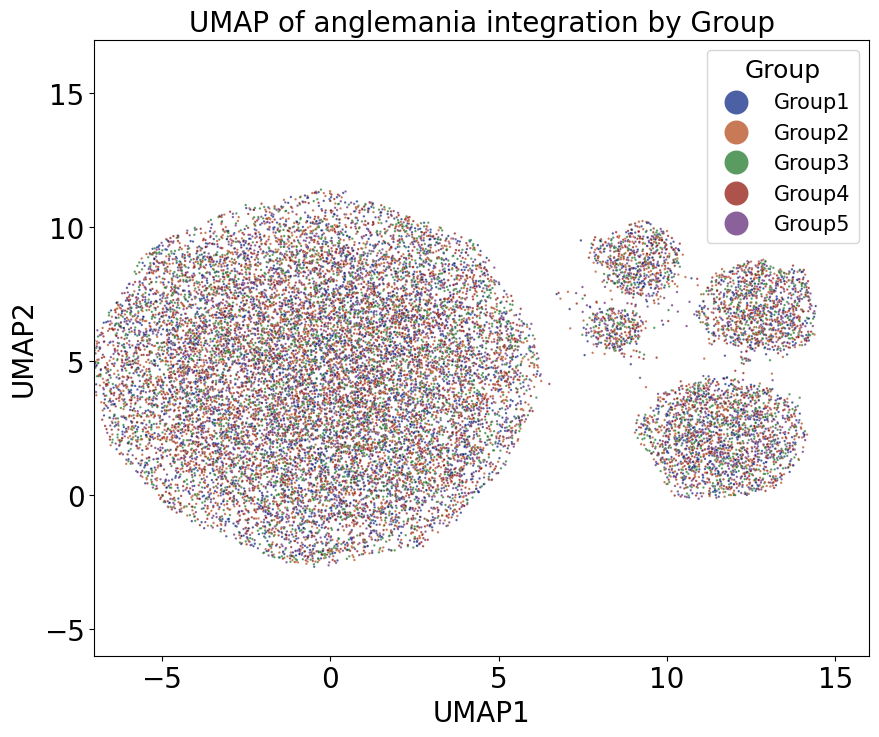

In [6]:
adata_angl = sc.read_h5ad("/data/akalin/akollot/anglemania_benchmark/simulated/integration/batch.facLoc0_de.facLoc0_nbatch5_ngroup5_groupCells800/scvi/batch.facLoc0_de.facLoc0_nbatch5_ngroup5_groupCells800_angl.h5ad")
adata_angl = prep_umap(adata_angl)
p = plot_umap(
    adata_angl, 
    color_by="Group",
    point_size=3
    )
p.set_title('UMAP of anglemania integration by Group', fontsize = 20)

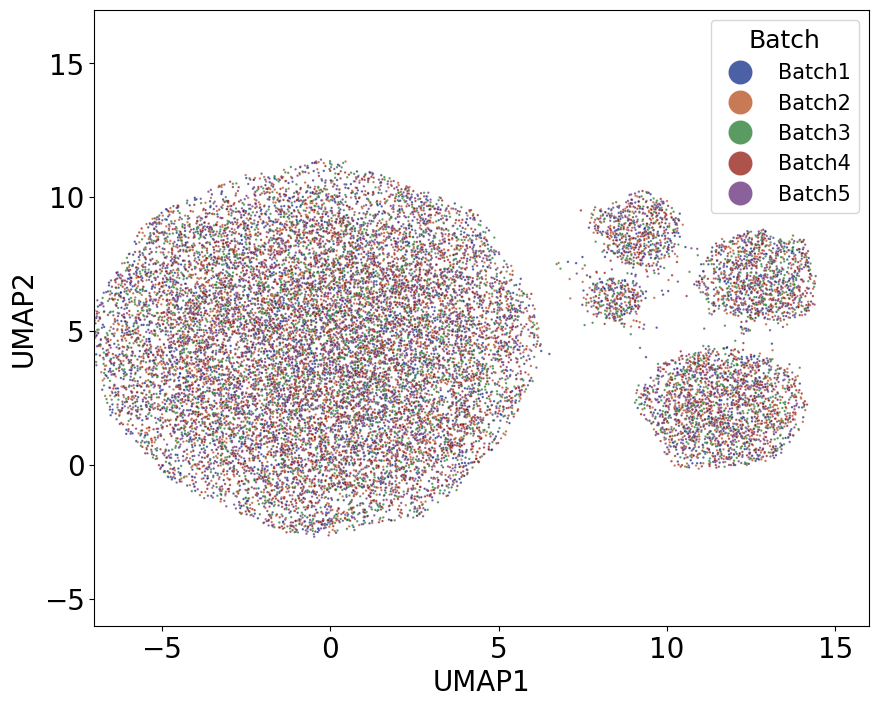

In [9]:
p = plot_umap(
    adata_angl, 
    color_by="Batch",
    point_size=3
    )

Text(0.5, 1.0, 'UMAP of anglemania integration by Group')

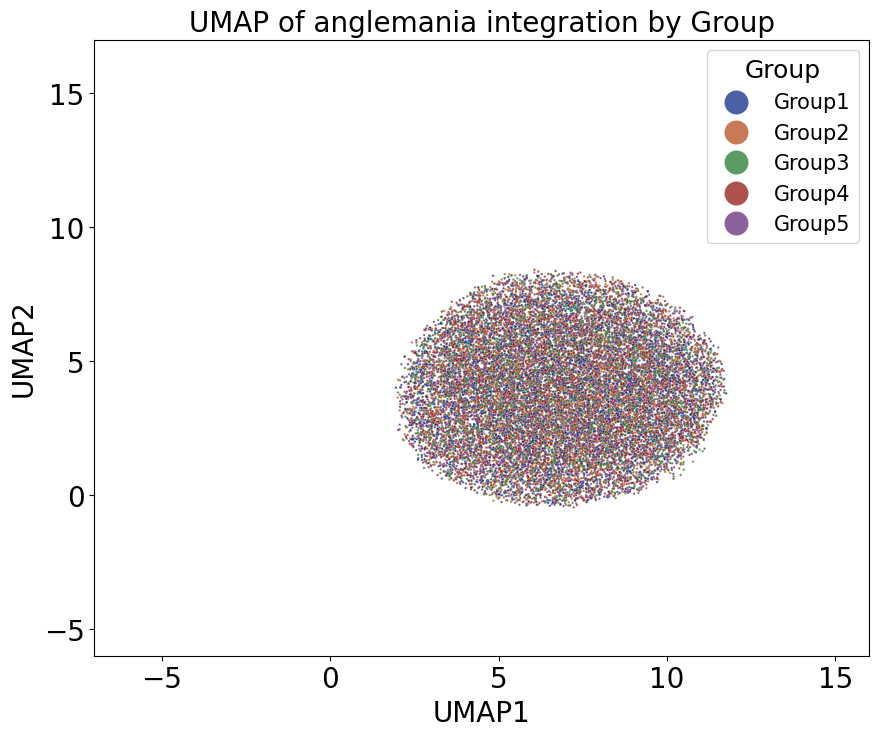

In [8]:
adata_hvg = sc.read_h5ad("/data/akalin/akollot/anglemania_benchmark/simulated/integration/batch.facLoc0_de.facLoc0_nbatch5_ngroup5_groupCells800/scvi/batch.facLoc0_de.facLoc0_nbatch5_ngroup5_groupCells800_hvg.h5ad")
adata_hvg = prep_umap(adata_hvg)
p = plot_umap(
    adata_hvg, 
    color_by="Group",
    point_size=3
    )
p.set_title('UMAP of HVG integration by Group', fontsize = 20)

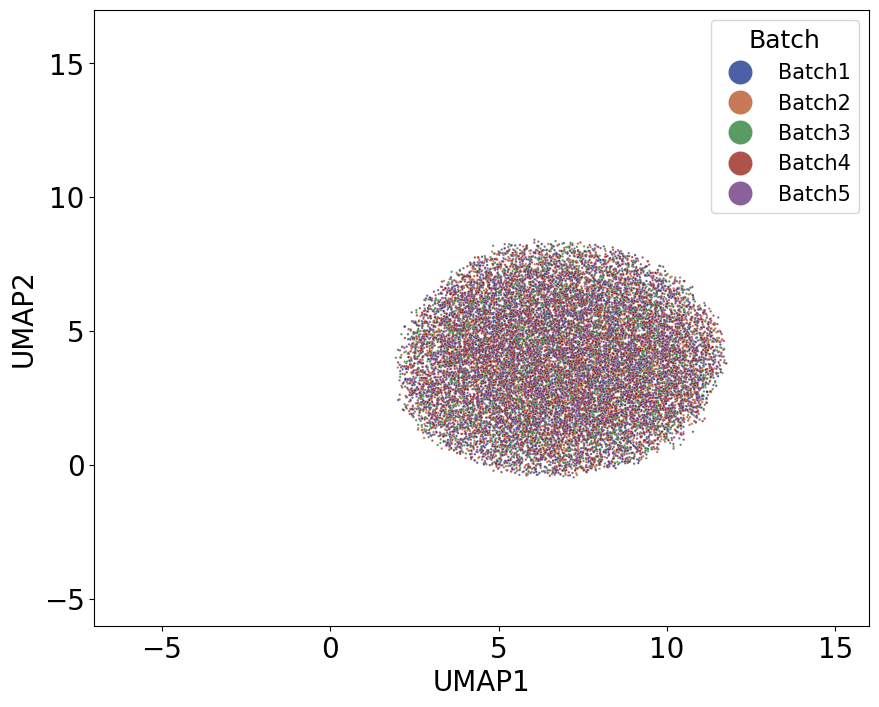

In [10]:
p = plot_umap(
    adata_hvg, 
    color_by="Batch",
    point_size=3
    )